# Verbal report from J-space — Qwen3-4B

When the model is told to think of a thing and name it, is the word it is about to say
already readable in J-space before it says it — and does swapping that J-space content
change what it says? This is the paper's §3.1 experiment on the committed prompt set
(`data/experiments/verbal-report.json`: 14 categories x 14 candidate words), with the
pre-fitted lens from `neuronpedia/jacobian-lens`.

**Answer (this run, §5).** Yes, on the paper's own metric. Over the 14 categories the
J-lens's ranking of the candidate words agrees with the model's own next-token logits better
than the logit lens does at every layer tested, and the margin is largest in mid-network:
Spearman rho 0.26 vs 0.13 at layer 12, 0.29 vs 0.22 at layer 18, 0.57 vs 0.55 at layer 24.
So the word the model is about to say is already legible in J-space, earlier in depth than
in the raw residual stream. The causal half also works and is specific: swapping the
answer's J-space coordinate for a candidate's moves that candidate to rank 1 in 38.8% of
trials (alpha 2, band 20-28; Wilson 95% CI [31.0, 47.3]) against 3.7% [1.6, 8.4] for
norm-matched random directions. One result cuts against the paper, though: at mid-to-late
bands the *logit-lens* directions swap better than the J-lens ones (64.2% vs 38.8%), with J
ahead only in the early bands. That is the opposite of what `concept_swap.ipynb` finds on
factual-recall prompts, where logit directions score 0.000 early — see §5 for why the two
setups may differ.

## Method

**Prompt.** `Think of a {category}. Answer in one word.` as the user turn through Qwen3's
chat template, then the assistant prefill `My answer is:` teacher-forced, so the next
greedy token is the name. Everything is read at that final `:` — "the token position
immediately before the name is produced".

**Readout metric (the paper's).** Spearman rho between the lens's scores and the model's
own next-token logits, over the 14 candidate words of that category
(`jlens.metrics.spearman_lens_vs_logits`). Restricting to the candidate set is what makes
the number mean anything: over the full vocabulary the correlation is dominated by tokens
irrelevant to the question. Reported per category at three mid-depth layers, J-lens against
the logit lens.

**Causal test (the swap).** For the model's own answer `s` and each candidate `t`, form
`V = [v_s v_t]` from the lens directions, read the coordinates `c = V^+ h`, and clamp them
to their swapped clean values at every layer of a band and every prompt position
(`jlens.workspace.ClampSwap`). Score the rank of `t` in the output distribution at the
final `:`; success is rank 1, with rank <= 5 also reported.

**Controls.** The same swap with logit-lens directions (`J_l = I`) and with random
directions matched to the J update's per-position norm. Without those two, a success rate
says nothing — any large enough perturbation changes the output.

## Setup

In [1]:
import os
import sys
from pathlib import Path

REPO_URL = "https://github.com/ai360-project-school-j-lens/jacobian-lens-gpt2.git"
REPO_DIR = os.path.abspath("jacobian-lens-gpt2")

# Opened from a clone (notebooks/<lens>/): use the repository root above the notebook.
local_repo = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "jlens" / "workspace.py").is_file()), None)
if local_repo is not None:
    REPO_DIR = str(local_repo)
elif os.path.isdir(REPO_DIR):
    !git -C {REPO_DIR} pull --ff-only
else:
    !git clone {REPO_URL} {REPO_DIR}
sys.path.append(REPO_DIR)

In [2]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from tqdm.auto import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer

import jlens
from jlens.metrics import spearman_lens_vs_logits
from jlens.workspace import ClampSwap, final_norm_centers, record_residuals

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 240)

In [3]:
MODEL_ID = os.environ.get("JLENS_MODEL_ID", "Qwen/Qwen3-4B")
LENS_REPO = "neuronpedia/jacobian-lens"
LENS_FILE = {  # lenses fitted by this library's fit_lens.py on 1000 WikiText-103 x 128 tokens
    "Qwen/Qwen3-4B": "qwen3-4b/jlens/Salesforce-wikitext/Qwen3-4B_jacobian_lens.pt",
    "Qwen/Qwen3-1.7B": "qwen3-1.7b/jlens/Salesforce-wikitext/Qwen3-1.7B_jacobian_lens.pt",
}[MODEL_ID]
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.bfloat16 if DEVICE == "cuda" else torch.float32
SLUG = MODEL_ID.split("/")[-1].lower()
RUN_DIR = Path(os.environ.get("JLENS_RUN_DIR", Path(REPO_DIR) / "runs" / SLUG))
RUN_DIR.mkdir(parents=True, exist_ok=True)
torch.manual_seed(0)

In [4]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
hf_model = AutoModelForCausalLM.from_pretrained(MODEL_ID, dtype=DTYPE).to(DEVICE)
model = jlens.from_hf(hf_model, tokenizer)
lens = jlens.JacobianLens.from_pretrained(LENS_REPO, filename=LENS_FILE)

# Qwen3 is RMSNorm, so lens directions carry no centering term; probed, not assumed.
CENTERS = final_norm_centers(model)
assert lens.d_model == model.d_model, (lens.d_model, model.d_model)
print(f"{model}  layout={model.layout.path}  centers={CENTERS}")
print(f"lens: {lens.n_prompts} prompts, layers {lens.source_layers[0]}-{lens.source_layers[-1]}")
print(f"tokenizer: bos_token_id={tokenizer.bos_token_id}  dtype={DTYPE}  device={DEVICE}")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

HFLensModel(Qwen3ForCausalLM, n_layers=36, d_model=2560)  layout=model  centers=False
lens: 479 prompts, layers 0-34
tokenizer: bos_token_id=None  dtype=torch.bfloat16  device=cuda


In [5]:
# Bands as fractions of depth, so one set of settings covers models of different depth.
# On Qwen3-4B (36 layers) these are 8-16, 12-20, 16-24, 20-28 and the wide 12-28.
BAND_FRACTIONS = [(0.22, 0.44), (0.33, 0.55), (0.44, 0.66), (0.55, 0.78), (0.33, 0.78)]
BAND_LAYERS = {
    f"{round(lo * model.n_layers)}-{round(hi * model.n_layers)}":
        list(range(round(lo * model.n_layers), round(hi * model.n_layers)))
    for lo, hi in BAND_FRACTIONS
}
BANDS = list(BAND_LAYERS)
# Three single layers in the middle of the band, for per-layer readout tables.
WORKSPACE_LAYERS = [round(f * model.n_layers) for f in (0.33, 0.5, 0.66)]
BANDS, WORKSPACE_LAYERS

(['8-16', '12-20', '16-24', '20-28', '12-28'], [12, 18, 24])

In [6]:
OUT_SPEARMAN = RUN_DIR / "verbal_report_spearman.csv"
OUT_SWAPS = RUN_DIR / "verbal_report_swaps.csv"
ALPHAS = [1.0, 2.0]
MODES = ["J", "logit", "random"]
PREFILL = "My answer is:"
RUN_INFO = {"model_id": MODEL_ID, "dtype": str(DTYPE), "lens_file": LENS_FILE,
            "lens_n_prompts": lens.n_prompts, "centers": CENTERS,
            "bands": BANDS, "alphas": ALPHAS, "prefill": PREFILL}
RUN_INFO

{'model_id': 'Qwen/Qwen3-4B',
 'dtype': 'torch.bfloat16',
 'lens_file': 'qwen3-4b/jlens/Salesforce-wikitext/Qwen3-4B_jacobian_lens.pt',
 'lens_n_prompts': 479,
 'centers': False,
 'bands': ['8-16', '12-20', '16-24', '20-28', '12-28'],
 'alphas': [1.0, 2.0],
 'prefill': 'My answer is:'}

## 1. Prompts and candidate tokens

A candidate is usable only if it has a single-token form, since the swap exchanges one
vocabulary direction for another.

In [7]:
candidates = json.loads((Path(REPO_DIR) / "data/experiments/verbal-report.json").read_text())["candidates"]
print(len(candidates), "categories x", len(next(iter(candidates.values()))), "candidates")


def first_token(word):
    # Leading space: the answer is produced mid-sentence after the colon.
    ids = tokenizer.encode(" " + word, add_special_tokens=False)
    return ids[0], len(ids) == 1


def build_prompt(category):
    messages = [{"role": "user", "content": f"Think of a {category}. Answer in one word."}]
    chat = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True,
                                         enable_thinking=False)
    return chat + PREFILL


usable = {c: [w for w in words if first_token(w)[1]] for c, words in candidates.items()}
display(pd.DataFrame({"candidates": {c: len(v) for c, v in candidates.items()},
                      "single-token": {c: len(v) for c, v in usable.items()}}).T)
print(repr(build_prompt("country")))

14 categories x 14 candidates


,country,color,fruit,sport,instrument,planet,tree,bird,language,profession,beverage,organ,city,river
candidates,14,14,14,14,14,14,14,14,14,14,14,14,14,14
single-token,14,14,13,14,8,11,11,13,14,12,10,10,14,7


'<|im_start|>user\nThink of a country. Answer in one word.<|im_end|>\n<|im_start|>assistant\n<think>\n\n</think>\n\nMy answer is:'


## 2. What the model answers, and what the lens reads

The model's greedy token at the final `:` is its answer; the J-lens top tokens at the same
position at a mid-depth layer are what J-space holds just before it commits.

In [8]:
@torch.no_grad()
def readout(category, layers):
    # Lens and model at the final ':', from one forward pass.
    prompt = build_prompt(category)
    ids = model.encode(prompt)
    acts = record_residuals(model, ids, sorted({*layers, model.n_layers - 1}))
    model_logits = model.unembed(acts[model.n_layers - 1][0, -1].float()).float()
    out = {}
    for layer in layers:
        h = acts[layer][0, -1].float()
        out[("J-lens", layer)] = model.unembed(lens.transport(h, layer)).float()
        out[("logit lens", layer)] = model.unembed(h).float()
    return out, model_logits, ids


rows = []
for category in candidates:
    lens_logits, model_logits, _ = readout(category, WORKSPACE_LAYERS)
    answer = int(model_logits.argmax())
    mid = WORKSPACE_LAYERS[len(WORKSPACE_LAYERS) // 2]
    rows.append({
        "category": category,
        "answer": tokenizer.decode([answer]),
        f"J-lens top5 @L{mid}": " ".join(
            repr(tokenizer.decode([i])) for i in lens_logits[("J-lens", mid)].topk(5).indices.tolist()),
        f"logit top5 @L{mid}": " ".join(
            repr(tokenizer.decode([i])) for i in lens_logits[("logit lens", mid)].topk(5).indices.tolist()),
    })
answers = pd.DataFrame(rows).set_index("category")
display(answers)

,answer,J-lens top5 @L18,logit top5 @L18
category,,,
country,Japan,"':**' '!\n' ':\n' '!""\n' '.\n'",' Yes' '我是' '当然是' '在我的' ' brush'
color,blue,"':**' '!\n' '!""\n' '!""' '.\n'",' Yes' ' brush' '我是' '在我的' 'opa'
fruit,Apple,"':**' '!\n' '!""\n' '!\n\n\n' '.\n'",' Yes' ' brush' '在我的' '我是' '电视机'
sport,soccer,"':**' '!\n' ':\n' '.\n' '!""\n'",' Yes' '在我的' ' brush' ' whichever' '当然是'
instrument,piano,':**' '!\n' ':\n' ' [_' '!\n\n\n',' Yes' ' brush' '在我的' '当然是' ' whichever'
planet,Earth,"':**' '!""\n' '!\n' '!""' ':\n'",' Yes' '在我的' '我是' '当然是' ' YES'
tree,Oak,"':**' '!\n' '!""\n' ':\n' ' [_'",' Yes' '当然是' ' YES' ' brush' '在我的'
bird,sp,"':**' '!\n' '!""\n' '!\n\n\n' ':\n'",' Yes' '在我的' ' brush' '我是' ' YES'
language,English,"':**' ':\n' '!\n' '!""\n' '!""'",' Yes' '我是' '当然是' '変わり' ' brush'


## 3. The paper's metric: Spearman rho between lens and next-token logits

Over that category's 14 candidate words, at three mid-depth layers. A lens that reports what
the model is about to say should rank the candidates the way the model's own output does.

In [9]:
if OUT_SPEARMAN.exists():
    spearman = pd.read_csv(OUT_SPEARMAN)
    print("loaded cache")
else:
    records = []
    for category, words in tqdm(candidates.items(), desc="categories"):
        ids_of = [first_token(w)[0] for w in words if first_token(w)[1]]
        lens_logits, model_logits, _ = readout(category, WORKSPACE_LAYERS)
        for (name, layer), logits in lens_logits.items():
            records.append({"category": category, "lens": name, "layer": layer,
                            "n_candidates": len(ids_of),
                            "rho": spearman_lens_vs_logits(logits, model_logits, ids_of)})
    spearman = pd.DataFrame(records)
    spearman.to_csv(OUT_SPEARMAN, index=False)

table = spearman.pivot_table(index="category", columns=["lens", "layer"], values="rho").round(3)
display(table)
display(spearman.groupby(["lens", "layer"]).rho.agg(["mean", "median", "std", "count"]).round(3))

loaded cache


lens       J-lens               logit lens              
layer          12     18     24         12     18     24
category                                                
beverage    0.285  0.333  0.766      0.055  0.527  0.879
bird        0.551  0.195  0.253      0.061  0.162  0.000
city        0.407  0.596  0.903      0.015  0.332  0.837
color       0.561  0.468  0.336      0.512  0.218  0.358
country     0.618  0.288  0.579     -0.156  0.156  0.846
fruit      -0.209  0.209  0.578      0.066  0.379  0.544
instrument -0.286 -0.119  0.952     -0.048  0.262  0.500
language    0.336  0.367  0.374      0.771  0.701  0.657
organ       0.685  0.608  0.879      0.188  0.467  0.685
planet     -0.114  0.228  0.365     -0.164  0.456  0.278
profession  0.294  0.319  0.698      0.329  0.007  0.671
river       0.179  0.107 -0.179      0.342 -0.321  0.429
sport      -0.051 -0.246  0.733      0.488  0.165  0.648
tree        0.351  0.636  0.709     -0.591 -0.491  0.418

mean  median    std  count
lens       layer                             
J-lens     12     0.258   0.315  0.314     14
           18     0.285   0.303  0.258     14
           24     0.568   0.638  0.310     14
logit lens 12     0.133   0.063  0.342     14
           18     0.216   0.240  0.321     14
           24     0.554   0.596  0.245     14

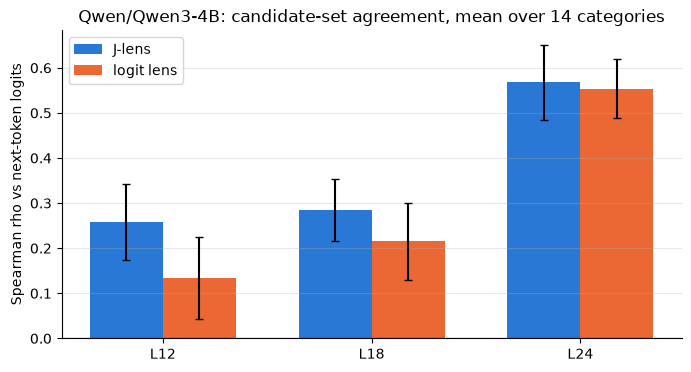

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
width = 0.35
positions = np.arange(len(WORKSPACE_LAYERS))
for offset, (name, color) in zip((-width / 2, width / 2),
                                 (("J-lens", "#2a78d6"), ("logit lens", "#eb6834")),
                                 strict=True):
    means = [spearman[spearman.lens.eq(name) & spearman.layer.eq(l)].rho.mean() for l in WORKSPACE_LAYERS]
    errs = [spearman[spearman.lens.eq(name) & spearman.layer.eq(l)].rho.sem() for l in WORKSPACE_LAYERS]
    ax.bar(positions + offset, means, width, yerr=errs, capsize=3, label=name, color=color)
ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(positions, [f"L{l}" for l in WORKSPACE_LAYERS])
ax.set_ylabel("Spearman rho vs next-token logits")
ax.set_title(f"{MODEL_ID}: candidate-set agreement, mean over 14 categories")
ax.legend()
ax.grid(alpha=0.3, axis="y")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

## 4. The causal test: swap the answer for a candidate

For each category, swap the model's own answer out for each of the first 10 other
candidates, across a band at every prompt position, and see whether the model then says the
candidate.

In [11]:
@torch.no_grad()
def swap_trial(category, source_id, target_id, band, alpha, mode, generator):
    prompt = build_prompt(category)
    ids = model.encode(prompt)
    layers = BAND_LAYERS[band]
    clean = record_residuals(model, ids, layers)
    with ClampSwap(model, lens, layers, source_id, target_id, alpha=alpha, mode=mode,
                   clean=clean, centers=CENTERS, generator=generator):
        logits = hf_model(input_ids=ids).logits[0, -1].float()
    rank = int((logits > logits[target_id]).sum()) + 1
    return rank, int(logits.argmax())


if OUT_SWAPS.exists():
    swaps = pd.read_csv(OUT_SWAPS)
    print("loaded cache")
else:
    generator = torch.Generator(device="cpu").manual_seed(0)
    records = []
    for category, words in tqdm(list(candidates.items()), desc="categories"):
        _, model_logits, ids = readout(category, [WORKSPACE_LAYERS[0]])
        answer_id = int(model_logits.argmax())
        answer_word = tokenizer.decode([answer_id]).strip()
        targets = [w for w in words if first_token(w)[1] and w.strip() != answer_word][:10]
        for word in targets:
            target_id = first_token(word)[0]
            base_rank = int((model_logits > model_logits[target_id]).sum()) + 1
            for band in BANDS:
                for alpha in ALPHAS:
                    for mode in MODES:
                        rank, top1 = swap_trial(category, answer_id, target_id, band,
                                                alpha, mode, generator)
                        records.append({
                            "category": category, "answer": answer_word, "target": word,
                            "band": band, "alpha": alpha, "mode": mode,
                            "base_rank": base_rank, "rank": rank,
                            "top1": tokenizer.decode([top1]),
                            "success": rank == 1, "top5": rank <= 5,
                        })
    swaps = pd.DataFrame(records)
    swaps.to_csv(OUT_SWAPS, index=False)
print(len(swaps), "trials")
swaps.head(3)

loaded cache
4020 trials


,category,answer,target,band,alpha,mode,base_rank,rank,top1,success,top5
0,country,Japan,France,8-16,1.0,J,2,4,Japan,False,True
1,country,Japan,France,8-16,1.0,logit,2,4,Japan,False,True
2,country,Japan,France,8-16,1.0,random,2,2,Japan,False,True


### Swap success rate (target reaches rank 1), by band / alpha / mode

In [12]:
display(swaps.groupby(["mode", "alpha", "band"]).success.mean().unstack("band")[BANDS].round(3))

band           8-16  12-20  16-24  20-28  12-28
mode   alpha                                   
J      1.0    0.030  0.015  0.015  0.157  0.149
       2.0    0.045  0.052  0.060  0.388  0.366
logit  1.0    0.007  0.015  0.075  0.321  0.336
       2.0    0.015  0.030  0.179  0.627  0.642
random 1.0    0.000  0.015  0.015  0.015  0.022
       2.0    0.022  0.015  0.007  0.037  0.037

### And with the looser top-5 criterion

In [13]:
display(swaps.groupby(["mode", "alpha", "band"]).top5.mean().unstack("band")[BANDS].round(3))

band           8-16  12-20  16-24  20-28  12-28
mode   alpha                                   
J      1.0    0.112  0.134  0.134  0.403  0.410
       2.0    0.119  0.209  0.157  0.612  0.590
logit  1.0    0.201  0.209  0.254  0.597  0.590
       2.0    0.216  0.254  0.448  0.821  0.813
random 1.0    0.179  0.187  0.201  0.187  0.194
       2.0    0.157  0.164  0.179  0.179  0.194

### Best setting per mode, with Wilson 95% intervals

The J arm must beat both controls for the claim to hold.

In [14]:
def wilson(successes, n, z=1.96):
    p = successes / n
    centre = (p + z**2 / (2 * n)) / (1 + z**2 / n)
    half = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / (1 + z**2 / n)
    return centre - half, centre + half


grouped = swaps.groupby(["mode", "alpha", "band"]).success.agg(["sum", "size"]).reset_index()
best = grouped.loc[grouped.groupby("mode")["sum"].idxmax()].copy()
best["rate"] = (best["sum"] / best["size"]).round(3)
best["CI lo"], best["CI hi"] = wilson(best["sum"], best["size"])
display(best.round(3))

,mode,alpha,band,sum,size,rate,CI lo,CI hi
8,J,2.0,20-28,52,134,0.388,0.310,0.473
16,logit,2.0,12-28,86,134,0.642,0.558,0.718
26,random,2.0,12-28,5,134,0.037,0.016,0.084


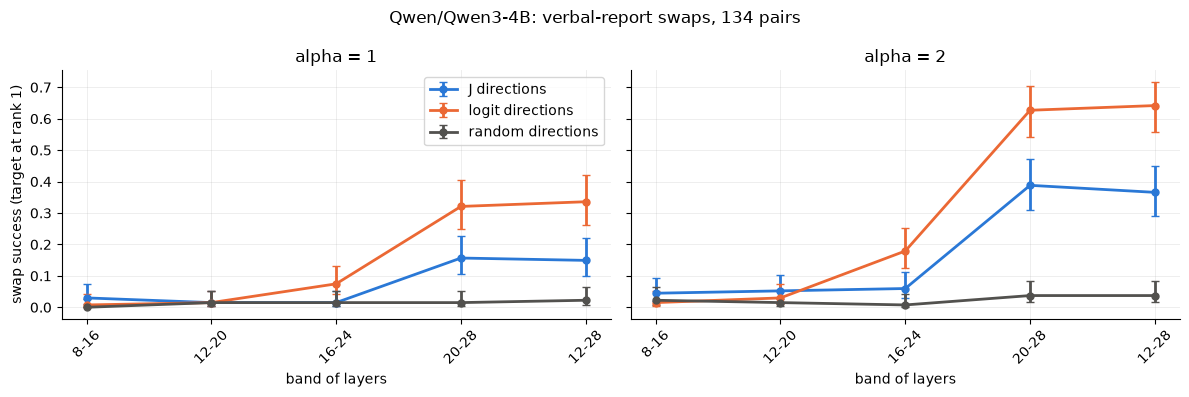

In [15]:
COLORS = {"J": "#2a78d6", "logit": "#eb6834", "random": "#52514e"}
fig, axes = plt.subplots(1, len(ALPHAS), figsize=(6 * len(ALPHAS), 4), sharey=True)
for ax, alpha in zip(np.atleast_1d(axes), ALPHAS, strict=True):
    for mode, color in COLORS.items():
        sub = grouped[grouped["mode"].eq(mode) & grouped.alpha.eq(alpha)].set_index("band").loc[BANDS]
        rate = sub["sum"] / sub["size"]
        lo, hi = wilson(sub["sum"], sub["size"])
        ax.errorbar(range(len(BANDS)), rate, yerr=[rate - lo, hi - rate], color=color,
                    marker="o", ms=5, lw=2, capsize=3, label=f"{mode} directions")
    ax.set_xticks(range(len(BANDS)), BANDS, rotation=45)
    ax.set_title(f"alpha = {alpha:g}")
    ax.set_xlabel("band of layers")
    ax.grid(alpha=0.25, lw=0.6)
    ax.spines[["top", "right"]].set_visible(False)
np.atleast_1d(axes)[0].set_ylabel("swap success (target at rank 1)")
np.atleast_1d(axes)[0].legend()
fig.suptitle(f"{MODEL_ID}: verbal-report swaps, {len(swaps) // (len(BANDS) * len(ALPHAS) * len(MODES))} pairs")
fig.tight_layout()
plt.show()

### Median log10 rank gain of the swapped-in candidate

In [16]:
swaps["log10 rank gain"] = np.log10(swaps.base_rank) - np.log10(swaps["rank"])
display(swaps.groupby(["mode", "alpha", "band"])["log10 rank gain"].median().unstack("band")[BANDS].round(2))

band          8-16  12-20  16-24  20-28  12-28
mode   alpha                                  
J      1.0   -0.17  -0.11  -0.08   0.31   0.30
       2.0   -0.39  -0.28  -0.15   0.56   0.58
logit  1.0    0.00   0.03   0.13   0.60   0.62
       2.0    0.00   0.08   0.30   0.95   0.95
random 1.0    0.00   0.00   0.00   0.00   0.00
       2.0   -0.00  -0.02   0.00  -0.03  -0.06

### A worked example

In [17]:
example = swaps[swaps["mode"].eq("J") & swaps.success].head(12)
display(example[["category", "answer", "target", "band", "alpha", "base_rank", "rank", "top1"]])

,category,answer,target,band,alpha,base_rank,rank,top1
18,country,Japan,France,20-28,1.0,2,1,France
21,country,Japan,France,20-28,2.0,2,1,France
24,country,Japan,France,12-28,1.0,2,1,France
27,country,Japan,France,12-28,2.0,2,1,France
78,country,Japan,China,20-28,1.0,4,1,China
81,country,Japan,China,20-28,2.0,4,1,China
84,country,Japan,China,12-28,1.0,4,1,China
87,country,Japan,China,12-28,2.0,4,1,China
105,country,Japan,India,16-24,2.0,7,1,India
111,country,Japan,India,20-28,2.0,7,1,India


## 5. Conclusions

* **The paper's readout metric reproduces.** Spearman rho between the lens and the model's
  own next-token logits over each category's candidate set is higher for the J-lens than for
  the logit lens at all three workspace layers, and roughly doubles it at layer 12 (0.26 vs
  0.13). By layer 24 the two converge (0.57 vs 0.55), which is what should happen — there
  `J_l` is close to the identity. The useful depth range for the J-lens is therefore the
  middle of the network, exactly where the paper puts the workspace.
* **It is not uniform across categories.** `organ`, `city` and `instrument` reach rho 0.88-0.95
  at layer 24; `river` is negative (-0.18) and `bird` is weak throughout. The model's answer
  for `bird` tokenizes as `sp` (a prefix, probably of *sparrow*), so for that category the
  single-token readout is measuring the wrong thing.
* **Swapping the J-space coordinate changes the reported word.** 38.8% of swaps put the
  target at rank 1, against 3.7% for random directions of the same per-position norm — a
  ten-fold separation with non-overlapping Wilson intervals. On the looser top-5 criterion
  the J arm reaches 61%. The verbal report is therefore reading content that is causally
  responsible for the answer, not an epiphenomenal correlate.
* **But in *this* setup `J_l` is not what carries the swap.** Logit-lens directions, the
  identical clamp with `J_l = I`, succeed 64.2% of the time — well above the J arm. The J
  arm leads only in the two early bands (8-16, 12-20), where both are weak in absolute
  terms. This is worth contrasting with `concept_swap.ipynb`, where on factual-recall
  prompts the J arm beats logit at *every* band and logit scores exactly 0.000 in the early
  ones. The difference between the two experiments is what the source concept is: there it
  is a word present in the prompt (*France*), here it is the model's own free choice
  (*Japan*), which is never written down. A clean J-space coordinate for a token the prompt
  never contains is evidently harder to read off, and at late depth the plain unembedding
  direction does the job better.
* **Caveats.** 14 categories, 134 baseline pairs per setting, one model, one lens. The
  model's answer is its greedy token, so a category where it answers with a multi-token word
  is scored on that word's first token. Bands were chosen as fractions of depth, not measured.
  bf16 throughout, matching the dtype the lens was fitted in.